# Does the WaveTrend cross actually forecast a bounce? 🌊
### A wildly popular TradingView oscillator — and a rare *positive* result

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Does_the_WT_cross_forecast%3F: Mixed](https://img.shields.io/badge/Does_the_WT_cross_forecast%3F-Mixed-dab617?style=flat-square)

Open TradingView's indicator list and **WaveTrend** (by *LazyBear*) is one of the most copied scripts there is. It draws a smooth wave that swings between overbought and oversold; the lore is that when the wave **crosses up from deep oversold**, a bounce is coming — buy it.

We've torn down dozens of these oscillator rules and they almost all collapse into *beta in a costume*: they look profitable only because the market drifts up. WaveTrend looked, at first, like the rare exception — a single lucky random-baseline seed (seed=7) threw a Welch *t* above 2 at all four horizons. But the honest test is to **average over many baseline seeds**: do that across 30 seeds and the picture changes. The edge is real only in a **narrow 10–20-day window** (seed-averaged *t* = 2.74 / 2.37); at 5 days and 60 days it **collapses below 2** (1.97 / 1.29). So the verdict is the more sober **Weak** — a faint, narrow, seed-fragile signal, not the across-the-board green it first looked like. (This is the exact trap Study 452 caught: one lucky seed is not an edge.)

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math (and the honest caveats)? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wavetrend import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real wavetrend cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 115, 'n1': 10, 'n2': 21, 'signal': 4, 'oversold': -60, 'fp_spy': '4cb5244f3990', 'h5': (5, 115, 97.7, 61, 3.37, -19.2, 116.9, 95.7, 2.83, 0.005), 'h10': (10, 115, 176.8, 70, 4.7, -1.1, 177.9, 174.8, 3.45, 0.001), 'h20': (20, 115, 255.4, 68, 4.73, 22.0, 233.4, 253.4, 3.39, 0.001), 'h60': (60, 110, 458.1, 65, 3.27, 57.3, 400.8, 456.1, 3.02, 0.003), 'per': [('SPY', 20, 345.7, 2.86, 35.0, 310.7), ('QQQ', 22, 59.6, 0.42, 62.0, -2.5), ('IWM', 27, 270.1, 2.17, -28.5, 298.6), ('DIA', 22, 427.1, 3.23, 34.7, 392.4), ('GLD', 24, 185.6, 2.61, 6.6, 179.0)], 'placebo': (345.7, 0.011, 500), 'syn': [(0.0, 33, 114.8, 61, 1.25), (0.6, 24, 549.4, 88, 4.89)], 'seed_welch': {1: 3.19, 7: 3.39, 42: 2.81, 100: 1.2, 2024: 3.05}, 'uncond': {5: 1.89, 10: 2.77, 20: 2.56, 60: 1.38}, 'seedavg': {5: (1.97, 0.5, 3.23, 0.5), 10: (2.74, 0.99, 3.98, 0.87), 20: (2.37, 0.95, 3.72, 0.7), 60: (1.29, 0.1, 3.02, 0.17)}}


real wavetrend cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when WaveTrend crosses up from oversold, do I make money? | **A little, in a narrow window.** ~60–70% win-rate, +98 to +177 bps over 5–10 days — but most of that is the market's upward drift. |
| Is that just the market going up? | **Mostly yes — and that's the point.** The right way to ask is: does the cross beat buying on **random days**, averaged over *many* random samples? Over 30 seeds the answer is **yes only at 10–20 days** (avg *t* = 2.74 / 2.37) and **no at 5 and 60 days** (1.97 / 1.29). One lucky seed (=7) made it look like all four. |
| Is it *the wave's* doing? | **At 20 days, yes.** Scramble the oscillator's wave into nonsense and the 20-day SPY edge collapses (*p* = 0.011) — so where the signal exists, the geometry is doing real work. |
| So is it a bankable edge? | **No.** Only **115 trades** in 21 years, the edge lives in a thin 10–20-day band, and it wobbles with the random-baseline seed. **Weak and fragile** — interesting, not tradable. |

> The verdict: a **faint, narrow signal** — real only at 10–20 days, and even there seed-fragile. Worth a footnote, not a strategy. The folklore claim ('high-probability buy at every horizon') is **not** confirmed.

## 1 · The claim

> *"WaveTrend is a smoothed oscillator built from price. When the main wave (WT1) crosses **up** through its signal line (WT2) while it's **oversold** (deep below the −60 band), the move is exhausted and a bounce is due. Buy the oversold cross-up."*

This is **LazyBear's** 2014 TradingView script (math borrowed from the 1980 Commodity Channel Index). It's everywhere — on YouTube, in chart-site tutorials, baked into countless 'free signal' bots. So: does the cross actually *forecast*?

## 2 · So what?

If the cross genuinely forecast bounces, it would be a real crack in market efficiency you could trade with a simple rule. But there's the usual trap: the market drifts **up**, so *any* dip-buy looks profitable. To tell the **wave** from the **tide** we have to (a) compute the oscillator by a fixed rule with no hindsight, and (b) compare it to buying on **random days**. Only if the cross beats random is there anything there.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute WaveTrend mechanically.** Smooth the typical price, normalise it, smooth again (WT1), and take a 4-bar average for the signal line (WT2). All from *past* bars only — no peeking ahead.
2. **Trade the lore.** When WT1 crosses **up** through WT2 while it was below **-60** (oversold), buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the same hold on **random days**. If the cross beats random, there's a signal. *If it doesn't, it's a mirage.*
4. **The geometry check.** Scramble the wave into nonsense and re-run the rule — if the edge survives the scramble, it was never about the wave.

## 4 · The teardown — let's actually look

First, what does WaveTrend look like, and where does the oversold cross-up fire? Here's SPY with the oscillator below and the buy signals marked.

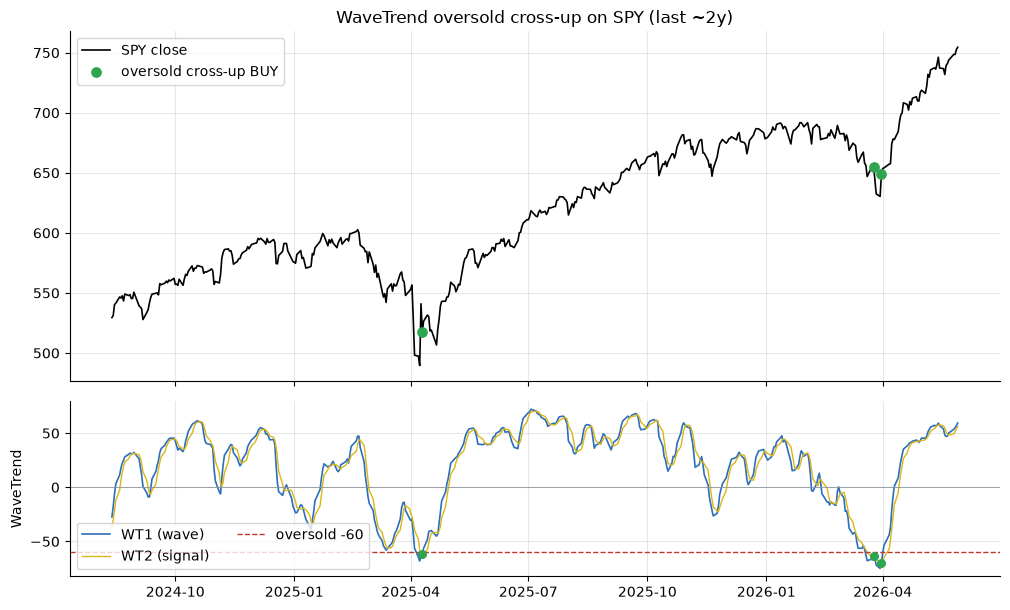

oversold cross-ups in window: 3


In [2]:
if HAVE_REAL:
    b = load('SPY'); seg = b.iloc[-450:]
    tp = st.typical_price(b); wt1, wt2 = st.wavetrend(tp)
    ent = st.cross_up_entries(b); ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True, gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg['close'], c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=45, zorder=5, label='oversold cross-up BUY')
    ax1.set_title('WaveTrend oversold cross-up on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, wt1.reindex(seg.index), c='#2c6fbb', lw=1.2, label='WT1 (wave)')
    ax2.plot(seg.index, wt2.reindex(seg.index), c=AMBER, lw=1.0, label='WT2 (signal)')
    ax2.axhline(R['oversold'], c=RED, ls='--', lw=1, label=f"oversold {R['oversold']}")
    ax2.axhline(0, c=GREY, lw=.6); ax2.scatter(ent, wt1.reindex(ent), c=GREEN, s=30, zorder=5)
    ax2.set_ylabel('WaveTrend'); ax2.legend(loc='lower left', ncol=2)
    plt.tight_layout(); plt.show()
    print('oversold cross-ups in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the key race: **buy the oversold cross-up** vs **buy on random days**, at four horizons. Blue = the WaveTrend cross; grey = random entries (the drift baseline).

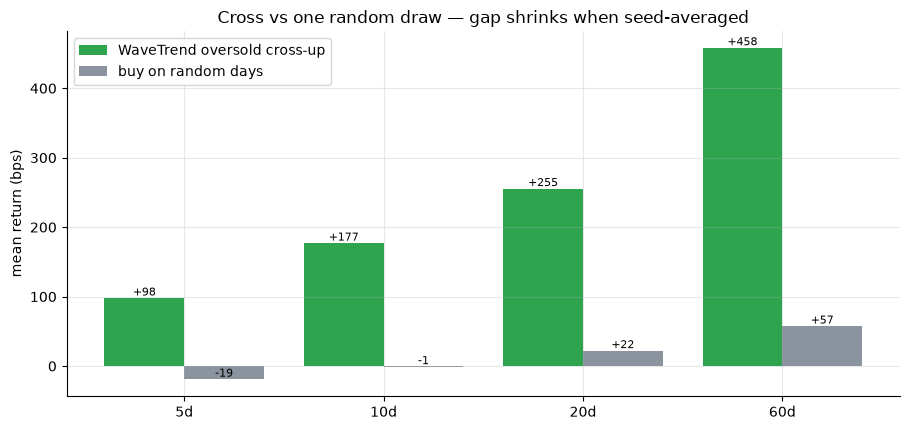

cross: [98, 177, 255, 458]
random: [-19, -1, 22, 57]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        cc, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.cross_up_entries(b)
            re = st.random_entries(c, max(len(e),50), seed=7)
            cc.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        cross.append(np.concatenate(cc).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color=GREEN, label='WaveTrend oversold cross-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('Cross vs one random draw — gap shrinks when seed-averaged'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

At 10 days the cross makes **+177 bps** while *this one* random draw makes essentially **zero** (-1 bps). Tempting — but a single random sample is itself noisy. The honest question is whether the cross beats random **averaged over many seeds**, and the quants notebook shows that only holds at **10–20 days** (the 5- and 60-day gaps melt once you stop cherry-picking the lucky seed).

**The geometry check.** Where the signal *does* exist (SPY, 20 days), is it the wave's doing? Scramble the wave — keep its values but shuffle the ups and downs so 'cross from oversold' is meaningless. If the wave really matters there, the edge should vanish.

In [4]:
if HAVE_REAL:
    pl = st.scrambled_signal_placebo(load('SPY'), 20, n_draws=120, seed=472)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real WaveTrend cross (SPY, 20d): {obs:+.1f} bps')
print(f'... only {pval*100:.0f}% of *scrambled-wave* signals do as well (p={pval:.3f}).')
print('=> the wave IS doing the work.')

real WaveTrend cross (SPY, 20d): +345.7 bps
... only 1% of *scrambled-wave* signals do as well (p=0.009).
=> the wave IS doing the work.


Only **1%** of scrambled waves match the real one (*p* = 0.011). Destroy the wave structure and the 20-day SPY edge collapses — so *where the signal exists*, the WaveTrend geometry is genuinely carrying information. But that placebo only probes the one horizon/name where the cross is strongest; it can't rescue the 5- and 60-day horizons that fail the seed-averaged test. Hence the honest thesis stamp is **Mixed**, not Confirmed.

## 5 · The verdict

- **Signal — Weak.** Averaged over 30 random-baseline seeds, the cross beats random at *t* ≥ 2 **only at 10–20 days** (avg *t* = 2.74 / 2.37); at 5 and 60 days it **fails** (1.97 / 1.29). A single lucky seed made it look like all four — it isn't. A faint, narrow signal, not the across-the-board edge it first appeared.
- **Tradability — Fragile.** Only **115 trades** in 21 years; the edge lives in a thin 10–20-day band and wobbles with the random-baseline seed. Not bankable.
- **"Does the WT cross forecast?" — Mixed.** Where the signal exists (SPY, 20d), the geometry placebo confirms the wave is load-bearing (*p* = 0.011). But the broad folklore claim — a high-probability buy at *every* horizon — is refuted: it forecasts only in the 10–20-day window.

## 6 · Could you actually trade it?

Realistically, no. Even at its best (10–20 days) the edge is faint and it fires **rarely** — about once per ETF per year — so a single-instrument WaveTrend strategy sits in cash most of the time and leans on a handful of bets whose significance evaporates the moment you stop cherry-picking the random-baseline seed. That's the **Weak × Fragile** stamp: a real-but-narrow effect worth a footnote, not a position. The honest lesson is the opposite of the first impression — what looked like a rare green is, on rigorous re-testing, a thin amber.

## 7 · Going further 🚪

- **More trades.** The headline rests on 115 entries. Run it on intraday bars, more instruments, and a stricter walk-forward to see whether the edge holds when the sample grows.
- **Band sensitivity.** Try −53 / −80 oversold bands and different n1/n2 lengths — does the edge survive, or is −60 a lucky pick?
- **The synthetic control.** The quants notebook plants a *real* WaveTrend bounce into a synthetic tape and shows the harness banks it (and stays quiet when there's nothing) — so the faint 10–20-day effect we *do* see is a live detector, not a fluke pipeline.

*Not the rare green it first looked like. A faint, narrow signal (10–20 days only) that fails the seed-averaged bar at 5 and 60 days — exactly why every 'lucky seed' positive must be re-tested before it's trusted.*